# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [120]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [122]:
# mostrar las primeras 5 filas de plans

plans.describe()

,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
std,282.842712,10.606602,353.553391,9.192388,0.141421,0.021213,0.021213
min,100.000000,5.000000,100.000000,12.000000,1.000000,0.050000,0.070000
25%,200.000000,8.750000,225.000000,15.250000,1.050000,0.057500,0.077500
50%,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
75%,400.000000,16.250000,475.000000,21.750000,1.150000,0.072500,0.092500
max,500.000000,20.000000,600.000000,25.000000,1.200000,0.080000,0.100000


In [123]:
# mostrar las primeras 5 filas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [124]:
# mostrar las primeras 5 filas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [125]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)  

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [126]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [127]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [128]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [129]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [130]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  En el caso de users, vemos 467 faltantes en cityy y 3534 en churn_date y en usage vemos 22076 faltantes en duration y 17896 en length
- Indica qué harías: ¿imputar, eliminar, ignorar? para el caso de  city en users es importante investigar porque es posible que se imputen por el porcentaje que rebasa el 5%, mientras que churn_date debe dejarse, es muy grande el nivel de ausencias pero debe ignorarse y dejar sin modifcavión porque quiere decir que no se han capturado pero no necesariamente son erróneos y en el caso de usage, tanto duration como length deben ser investigadas ya que tienen un porcentaje bastante ato y son columnas importantes para el análisis, por ello no se puede imputafr sin precaución. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [131]:

# explorar columnas numéricas de users
users.describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` se muestra como una columna estable en la que no hay datos anómalos, sino que se presnetan de manera regular y diistribuida, eso puede incluso verse en la cpincidencia de quartil que indica el 50% con el promedio que es idéntico
- La columna `age` muestra claramente un sentinel con el dato minimo de -999 el cuál puede tener diversas explicaciones pero es un rerror ya que no es una edad posible. En este caso debe  atenderse el dsato para cambiar por nulo y que no afecte a la desviación estandar ni al promedio. Si se cambia el -999 por nulo se puede reducir la desviación estandar. De igual manera valdría la pena revisar cuántas veces se presenta ese número.


In [132]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son columnas de datos estables en donde podemos ver que la media y la mediana coiniden. Hay una distribución simétrica. 
- Las columnas duration presenta umna media mayor que la mediana, por lo que se sigiere que tiene un sesgo  hacia la derecha, causado por el 120  como máximo puede representar a pocos eventos largos, lo cuál hace esa asimetría. Si bien genera séntinels debe contemplarse como un tipo de evento posible que no nos lleva a considerar su ajuste. Por otra parte con length vemos que mantiene una dispersi´pon ordenada y similar entre la media y la mediana, pero que si notamos la distrobución que hay entre el 75% de64 y el 1490 en el máximo nos refleja que sí hay outliers que deben ser atendidos para que no afecten a las métricas. 

In [133]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n{col}:")
    print(users[col].value_counts())



city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` presenta 96 registros desconocidos que se marcaron con el símbolo ?. Estos deben unificarse con los 469 que ya se habían identificado previamente para analizar las posibles acciones.
- La columna `plan` no muestra faltantes y nos revela solo  las cantidades de usuariso en cada plan, en donde son superiores los del plan básico. 

In [134]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` es una columna ordentada con datos que  muestran un balance en los dos tipos de acciones, calls y texts. Esta columna se puede cruzar con otras para comprender los faltantes.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  En la columna city vemos caramente los datos eróneos, los cuáles no son pocos y en age encontramos los sentinels de -999 que claramente distorcionan las métricas. 
- ¿Qué acción tomarías?  En el caso de city deben anular, pero en el caso de age, estos podrían contarse en la moda, sin embargo  no hay razón alguna para descartar las otras ciudades, lo más conveniente es dejarlo como nulo y excluirlo de los análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [135]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date']  = pd.to_datetime(users['reg_date'], errors='coerce')


In [136]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [137]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, exkisten 40 datos imposibles que están asignados a 2026

In [138]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date` parece que se tiene una columna en orden porque no hay numero imposibles.   
Basaremos el análisis en estas fechas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Sí, en reg_date encontramos 2026 como un año imposible porque para lo que se pide, todo aquello después de 2024 sería imposible
- ¿Qué harías con ellas? Sería cambiar los registros de 2026 por NaN, porque no sabemos cuál es el valor real y es mejor que no se cuenten para los cálculos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [139]:


# Reemplazar -999 por la mediana de age
age_mediana = users[users['age']!= -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()



count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [140]:
# Veamos todos los valores únicos
print("Valores únicos en age:")
print(sorted(users['age'].unique()))

Valores únicos en age:
[18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0]


In [141]:
print("Tipo de datos de age:", users['age'].dtype)
print("Primeros 10 valores únicos:")
print(users['age'].unique()[:10])

Tipo de datos de age: float64
Primeros 10 valores únicos:
[38. 53. 57. 69. 63. 61. 39. 70. 76. 47.]


In [142]:
# Verificar si hay valores que no son números
print("¿Hay valores no numéricos?")
print(users['age'].apply(lambda x: not isinstance(x, (int, float, np.integer, np.floating))).sum())

¿Hay valores no numéricos?
0


In [143]:
# Veamos algunos valores de ejemplo
print("Primeros 20 valores de age:")
print(users['age'].head(20).tolist())

# Veamos qué pasa al convertir a numérico
users['age_numeric'] = pd.to_numeric(users['age'], errors='coerce')
print("\nValores únicos después de conversión:")
print(sorted(users['age_numeric'].dropna().unique())[:20])

Primeros 20 valores de age:
[38.0, 53.0, 57.0, 69.0, 63.0, 61.0, 39.0, 70.0, 76.0, 47.0, 67.0, 60.0, 48.0, 78.0, 77.0, 47.0, 25.0, 51.0, 74.0, 64.0]

Valores únicos después de conversión:
[18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0]


In [144]:
# Veamos el archivo original sin modificaciones
users_original = pd.read_csv('/datasets/users_latam.csv')
print("Tipo de datos original de age:", users_original['age'].dtype)
print("Primeros 10 valores originales:")
print(users_original['age'].head(10).tolist())
print("Valores únicos originales (primeros 20):")
print(sorted(users_original['age'].unique())[:20])

Tipo de datos original de age: int64
Primeros 10 valores originales:
[38, 53, 57, 69, 63, 61, 39, 70, 76, 47]
Valores únicos originales (primeros 20):
[-999, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


In [145]:
# Recargar la columna age desde el archivo original
users['age'] = users_original['age'].copy()

# Verificar que ahora tenemos los datos correctos
print("Tipo de datos:", users['age'].dtype)
print("Valores únicos (primeros 20):")
print(sorted(users['age'].unique())[:20])

Tipo de datos: int64
Valores únicos (primeros 20):
[-999, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


In [146]:
# Calcular la mediana excluyendo los valores -999
age_mediana = users[users['age'] != -999]['age'].median()
print(f"Mediana de age (sin -999): {age_mediana}")

# Reemplazar -999 con la mediana
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar el resultado

print("Después de la limpieza:")
print(users['age'].describe())


Mediana de age (sin -999): 48.0
Después de la limpieza:
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [147]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print("Después de la limpieza:")
print(users['city'].describe())


Después de la limpieza:
count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object


In [148]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NA)

# Verificar cambios
print("Años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años después de la limpieza:


AttributeError: Can only use .dt accessor with datetimelike values

In [149]:
# Verificar el tipo de datos actual
print("Tipo de datos de reg_date:", users['reg_date'].dtype)
print("Primeros 5 valores:")
print(users['reg_date'].head())

Tipo de datos de reg_date: object
Primeros 5 valores:
0    1640995200000000000
1    1641018857914478619
2    1641042515828957239
3    1641066173743435858
4    1641089831657914478
Name: reg_date, dtype: object


In [150]:
# Convertir de nuevo a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Ahora sí verificar los años después de la limpieza
print("Años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años después de la limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


In [151]:
# Verificar el estado actual de reg_date
print("Tipo de datos actual:", users['reg_date'].dtype)
print("Primeros 5 valores:")
print(users['reg_date'].head())

# Convertir correctamente a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Verificar la conversión
print("\nDespués de la conversión:")
print("Tipo de datos:", users['reg_date'].dtype)
print("Primeros 5 valores:")
print(users['reg_date'].head())

Tipo de datos actual: datetime64[ns]
Primeros 5 valores:
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]

Después de la conversión:
Tipo de datos: datetime64[ns]
Primeros 5 valores:
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [152]:
# Marcar fechas futuras como NA para reg_date
#users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NA)

# Verificar cambios
#print("Años después de la limpieza:")
#print(users['reg_date'].dt.year.value_counts().sort_index())

In [153]:
# Primero, verificar el estado actual
print("Tipo de datos actual:", users['reg_date'].dtype)
print("Primeros 5 valores:")
print(users['reg_date'].head())

Tipo de datos actual: datetime64[ns]
Primeros 5 valores:
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [154]:
# Convertir correctamente a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Verificar la conversión
print("\nDespués de la conversión:")
print("Tipo de datos:", users['reg_date'].dtype)
print("Primeros 5 valores:")
print(users['reg_date'].head())


Después de la conversión:
Tipo de datos: datetime64[ns]
Primeros 5 valores:
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [155]:
# Ahora sí aplicar la limpieza de fechas futuras
#users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NA)

# Verificar los años después de la limpieza
#print("Años después de la limpieza:")
#print(users['reg_date'].dt.year.value_counts().sort_index())

In [156]:
# Primero, recargar la columna reg_date desde el archivo original
users_original = pd.read_csv('/datasets/users_latam.csv')
users['reg_date'] = pd.to_datetime(users_original['reg_date'], errors='coerce')

# Verificar que ahora tenemos datetime
print("Tipo de datos:", users['reg_date'].dtype)
print("Años antes de la limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Tipo de datos: datetime64[ns]
Años antes de la limpieza:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [157]:
# Verificar cuántos valores nulos hay en duration
print("Valores nulos en duration:")
print(usage['duration'].isnull().sum())
print(f"Porcentaje de nulos: {usage['duration'].isnull().mean()*100:.2f}%")


Valores nulos en duration:
22076
Porcentaje de nulos: 55.19%


In [158]:

# Crear una columna indicadora de nulos
usage['duration_missing'] = usage['duration'].isnull()


# Analizar relación con la columna type
print("Distribución de nulos por tipo de registro:")
crosstab = pd.crosstab(usage['type'], usage['duration_missing'], margins=True)
print(crosstab)

# Calcular porcentajes
print("\nPorcentaje de nulos por tipo:")
porcentajes = pd.crosstab(usage['type'], usage['duration_missing'], normalize='index') * 100
print(porcentajes)

Distribución de nulos por tipo de registro:
duration_missing  False   True    All
type                                 
call              17908      0  17908
text                 16  22076  22092
All               17924  22076  40000

Porcentaje de nulos por tipo:
duration_missing       False      True 
type                                   
call              100.000000   0.000000
text                0.072424  99.927576


In [159]:
# Verificación MAR en usage (Missing At Random) para length
# Verificar cuántos valores nulos hay en length
print("Valores nulos en length:")
print(usage['length'].isnull().sum())
print(f"Porcentaje de nulos: {usage['length'].isnull().mean()*100:.2f}%")


Valores nulos en length:
17896
Porcentaje de nulos: 44.74%


In [160]:
# Crear una columna indicadora de nulos para length
usage['length_missing'] = usage['length'].isnull()

# Analizar relación con la columna type
print("Distribución de nulos por tipo de registro:")
crosstab = pd.crosstab(usage['type'], usage['length_missing'], margins=True)
print(crosstab)

# Calcular porcentajes
print("\nPorcentaje de nulos por tipo:")
porcentajes = pd.crosstab(usage['type'], usage['length_missing'], normalize='index') * 100
print(porcentajes)

Distribución de nulos por tipo de registro:
length_missing  False   True    All
type                               
call               12  17896  17908
text            22092      0  22092
All             22104  17896  40000

Porcentaje de nulos por tipo:
length_missing       False      True 
type                                 
call              0.067009  99.932991
text            100.000000   0.000000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Duration: es MAR porque los dats nulos no tienen relacipon con alguna otra variable, lo que quiere decir que muestra un comportamiento esperado para esta variable. No es necesariuo imputar proque se pude esperar que  exista esta alto numero de nulos en calls, mientras que en text no.

En el caso de length encontramso un caso similar en el que o deben eliminarse los ulos, son parte d eun comportamiento esperado. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [161]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas




# Agrupar información por usuario

usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # suma total de mensajes
    'is_call': 'sum',      # suma total de llamadas  
    'duration': 'sum'      # suma total de minutos de llamadas
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [162]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [163]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,age_numeric,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,38.0,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,53.0,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,57.0,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,69.0,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,63.0,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [164]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,age_numeric,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,79.000000,17.000000,15.000000,155.690000


In [165]:

# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

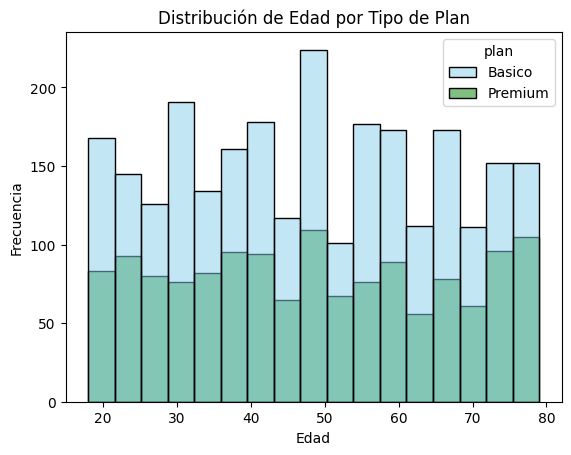

In [166]:

# Histograma para visualizar la edad (age)


sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- Distribución de edad por tipo d eplan se muestra balanceada con algunos picos pero con ciclos que se balancean. ElPlan Básico domina en preferencia por encima del Premium, pero esto no se puede atribuir a la diferencia de edades de los usuarios. 

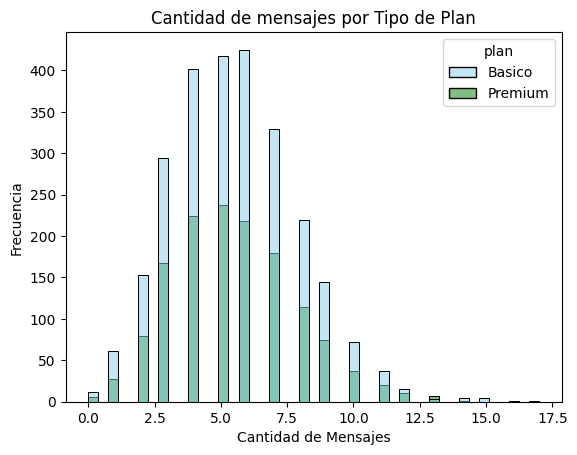

In [167]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()





💡Insights: 
- La diferencia entre losplanes básicos y premium sigue siendo la misma con preferencia pro el básico, pero aquí notamos un sesgo a la derecha por lo que se puede ver que  la mayoríua de los usuarios envían entre 3 y 7 mensajes y son pocos los que realizan más de 10.

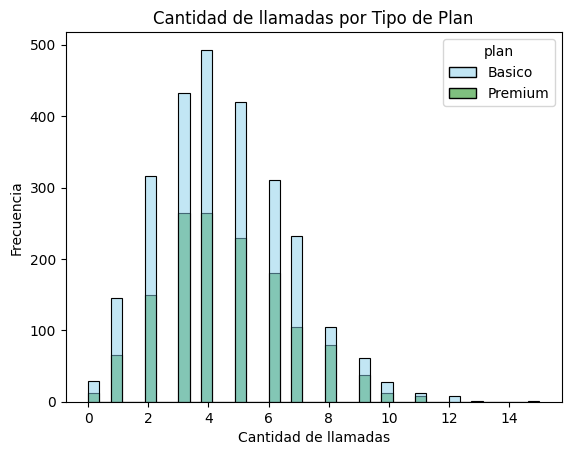

In [168]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de llamadas por Tipo de Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()




💡Insights:
La preferencia por el Plan Básico continúa. Se muestra un sesgo a la derecha. La mayoría d elos usuarios hace uso de entre 2 y 6 llamadas, mientras que una ninoría hace más de 10.

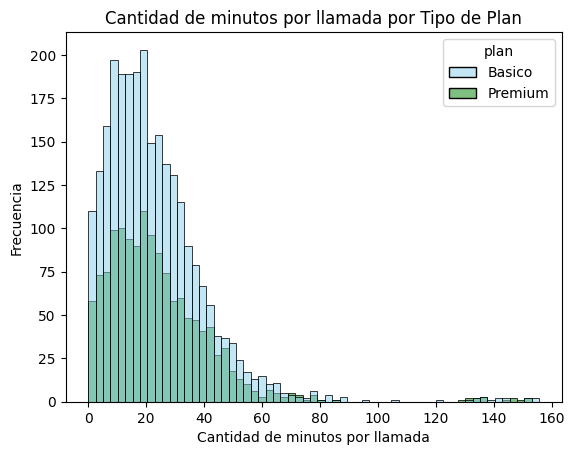

In [169]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de minutos por llamada por Tipo de Plan')
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- Tenemos un acaso similar con u sesgo a la derecha, sin embargo  dado que la concentracipon de usos de minutos por los usuarios está entre 0 y 40, se puede presumir que losdatos que sesgan a la derecha desde 100 hasta 160 se pueda tratar de outliers que merezacan atención y revisión. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

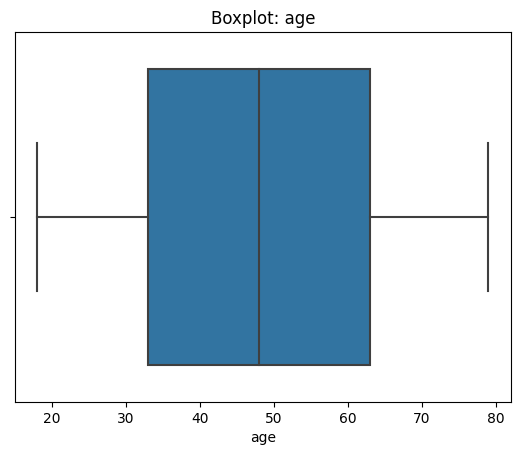

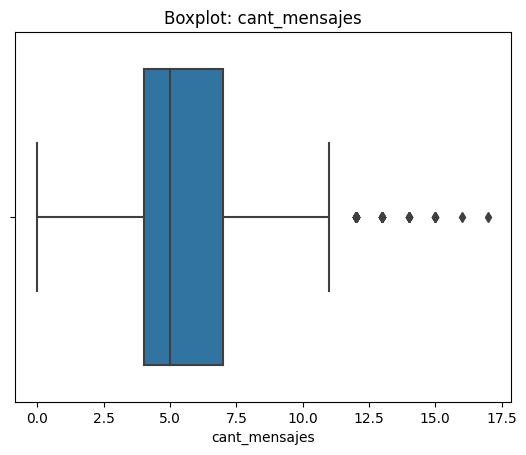

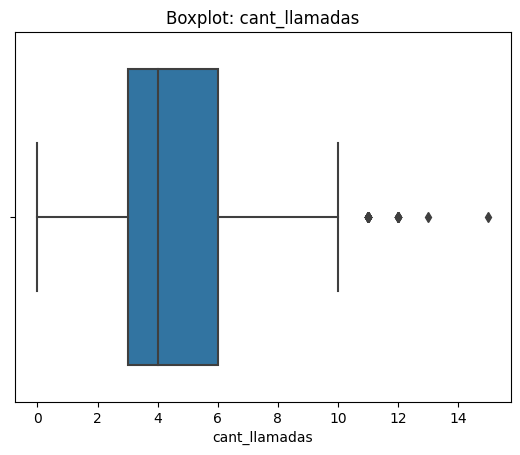

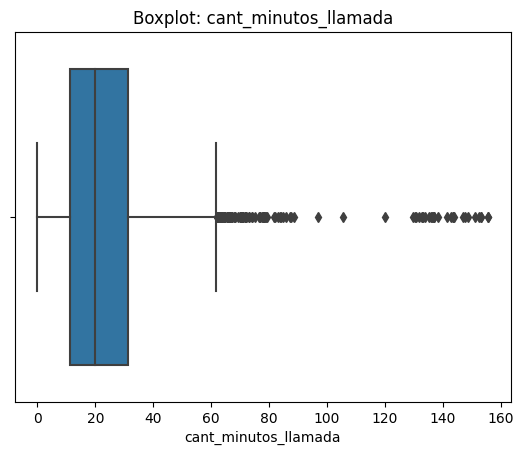

In [170]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)  # Cambiar users por user_profile
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: ...(presenta o no outliers) No presenta outliers, incluso los bigotes se extienden de forma simétrica
- cant_mensajes: presenta outliers que van desde los 11 hasta los 17 mensajes, mientras que las cantidades mayoritarias se concentran entre los 3 y 6 mensajes con sus respectivos bigotes.
- cant_llamadas: presenta oiutliers pues el promedio se las llamadas estpan entre 3 y6 llamadas, pero se encuentran datos extremso que se salen hasta entre 11 y 15 llamadas.
- cant_minutos_llamada: Presenta outliers claros, pues si bien el promedio estpa en los 20 minutos, temnemos datos que hacen un sesgo grave a la derecha con hasta 140 y 160 minutos. 

In [171]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    print(f"\n--- Análisis de {col} ---")
    Q1 = user_profile[col].quantile(0.25)
    print('Primer cuartil:', Q1)
    
    Q3 = user_profile[col].quantile(0.75)
    print('Tercer cuartil:', Q3)
    
    IQR = Q3 - Q1
    print('IQR:', IQR)
    
    lower = Q1 - 1.5 * IQR
    print('Límite inferior:', lower)
    
    upper = Q3 + 1.5 * IQR
    print('Límite superior:', upper)




--- Análisis de age ---
Primer cuartil: 33.0
Tercer cuartil: 63.0
IQR: 30.0
Límite inferior: -12.0
Límite superior: 108.0

--- Análisis de cant_mensajes ---
Primer cuartil: 4.0
Tercer cuartil: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

--- Análisis de cant_llamadas ---
Primer cuartil: 3.0
Tercer cuartil: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

--- Análisis de cant_minutos_llamada ---
Primer cuartil: 11.12
Tercer cuartil: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [172]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Se recomienda mantener lpos outliers, porque la diferencia entre el promedio (11 ) y el máximo (17)  hace un sesgo visible a la derecha éro no se trata de valores imposibles. 
- cant_llamadas: mantener o no outliers, porqué? Se recomienda mantener lpos outliers, porque la diferencia entre el promedio (10 ) y el máximo (15)  hace un sesgo visible a la derecha éro no se trata de valores imposibles. 
- cant_minutos_llamada: mantener o no outliers, porqué? Se recomienda mantenerlos pero estar bajo observación siempre-. Es posible un dato como ese pero poco probable. Hay que ver cómo se modifican las métricas antes de imputarlos. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [173]:

# Crear columna grupo_uso

grupo_uso = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 
        'Uso medio', 
        'Alto uso'
    )
)

# Asignar la nueva columna al DataFrame
user_profile['grupo_uso'] = grupo_uso


In [174]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,age_numeric,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,38.0,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,53.0,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,57.0,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,69.0,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,63.0,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [175]:
# Crear columna grupo_edad

grupo_edad = np.where(
    (user_profile['age'] < 30), 
    'Joven',
    np.where(
        (user_profile['age'] < 60), 
        'Adulto', 
        'Adulto Mayor'
    )
)

user_profile['grupo_edad'] = grupo_edad



In [176]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,age_numeric,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,38.0,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,53.0,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,57.0,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,69.0,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,63.0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

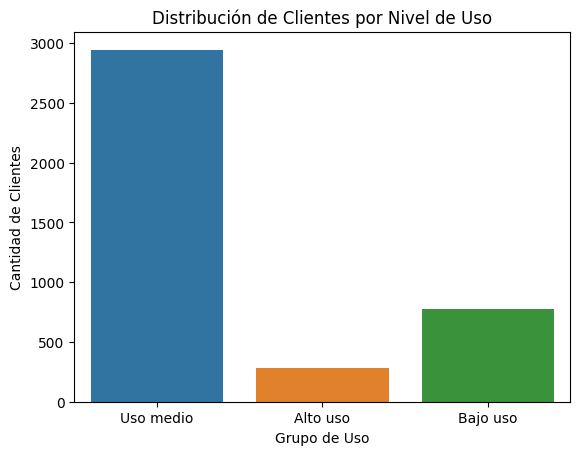

In [177]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Grupo de Uso')

plt.ylabel('Cantidad de Clientes')
plt.show()

plt.show()



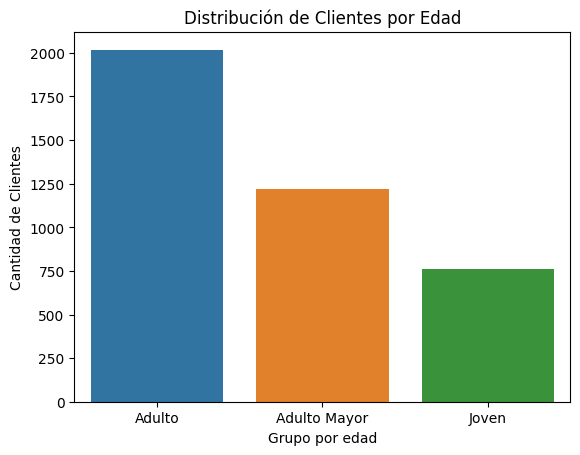

In [178]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Clientes por Edad')
plt.xlabel('Grupo por edad')

plt.ylabel('Cantidad de Clientes')
plt.show()

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
 Encontramos varios problemas que se enuncian en orden de aparción.
En primer lugar el  sentinel de -999 en agese reemplazó por NaN para que no estorbara y representaba solo el 1%  de los 4000 registros.

En city teniuamos 469 datos faltantes con NaN, más 96 qyue se registraron con ? los cuáles al unificarlos y sumarlos representaron el 14%

en reg_date, los múmero imposibles por ser de un año que no pasaba algún fue de 40 que representaba un 1%

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  El 50% de los ususarios pueden ubicarse entre los 30 y 60 años, pero es de notarv que un 30% se ubica pro arriba de los 60 años. Hay una media alta, pero con un  sector de adultso mayore spotencial. Los jóvenes son aquel grupo que menos responde a la oferta por lo que debe contemplarse como un átrea de oportunidad. No importando el rango de edad, se prefiere el Plan Básico por enciema del Premium- La edad no es factor.
- 
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué? No se debe descuidar el sector principal de entre 30 y 60, pero las cosas se pueden seguir hacviendo igual para que se mantengan, sin embargo, me parece que el sector más valioso por su potencial de crecimiento es el de mayores de 60 años. En términos de uso, si bien tenemos datos que se producen por outliers, es posible que los datos que se disparan sean reales, y por ello se puede ñponer atención a que los usuarios que tienen un alto uso pueden ser uns ector valioso de grandes ganancias y no se debe descartar. 
- 
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- Los usuarios del sector de alto uso estarían señalando un consumo de más de 11 mensajes y más de 10 llamadas, en el caso de que sean casos reales. Y en el caso extraño del outlier llamativo de minutos de llamadfa que se dispara hasta lso 160, si esos datso son reales representa el tipo de clientes premium que vale la pena analizar ára  promover un uso extenmdido en los usuarios que ahora están en la media. 


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
-  No se debe descuidar el sector principal de entre 30 y 60, pero las cosas se pueden seguir hacviendo igual para que se mantengan, sin embargo, me parece que el sector más valioso por su potencial de crecimiento es el de mayores de 60 años.
-  Un Plan que atienda a estos usuarios de un uso alto para que se multipliquen puede general grandes ganancias.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-En age encontramos un sentinel de -999 que representaba solo el 1% de los 4,000 registros y se reemplazó por NaN. En city había 469 datos faltantes más 96 registrados con ? que al unificarse sumaron el 14% de la columna. 

-En reg_date aparecieron 40 fechas del año 2026, imposibles para el dataset, representando otro 1%.
duration y length tenían nulos altos (55% y 44%) pero no son un problema real: se confirmó que son nulos estructurales según el tipo de evento, por lo que se dejaron como están.


🔍 **Segmentos por Edad**
-El 50% de los usuarios se ubica entre los 30 y 60 años, pero vale notar que un 30% supera los 60, lo que representa un sector de adultos mayores con potencial interesante. Los jóvenes son el grupo que menos responde a la oferta actual y deben contemplarse como área de oportunidad.

-No importando el rango de edad, se prefiere el Plan Básico sobre el Premium. La edad no es un factor determinante en la elección del plan.

📊 **Segmentos por Nivel de Uso**
-El 75% de los usuarios tiene un uso medio, el 19% un uso bajo y apenas el 8% un uso alto. Ese 19% de bajo uso es el que más atención requiere porque son los candidatos más probables a cancelar el servicio.

-Los outliers de uso parecen ser casos reales, no errores. Usuarios con más de 11 mensajes, 10 llamadas o hasta 160 minutos por llamada representan un perfil de cliente intensivo que vale la pena analizar y promover. Esto sugiere que: los usuarios de alto uso son un sector valioso de grandes ganancias que no se debe descartar, y que activar a los de bajo uso antes de que se vayan es una prioridad.

➡️ Esto sugiere que ...


💡 **Recomendaciones**
-El sector principal de entre 30 y 60 años no debe descuidarse, pero las cosas pueden seguir funcionando igual para mantenerlos. El mayor potencial de crecimiento está en los mayores de 60 y en los jóvenes, que hoy están subrepresentados.
Un plan orientado a los usuarios de alto uso, que les dé más por su consumo, puede multiplicar ese segmento y generar ganancias importantes sin necesidad de adquirir clientes nuevos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`